In [1]:
# STEP 1: IMPORT LIBRARIES

import os
import glob

import numpy as np

import nibabel as nib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv3D, MaxPooling3D, UpSampling3D,
                                     concatenate, BatchNormalization, Activation, Dropout)

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Nibabel Version: {nib.__version__}")

2026-03-20 13:55:19.614713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774014919.827807      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774014919.889021      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774014920.415170      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774014920.415211      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774014920.415214      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Nibabel Version: 5.3.3


In [2]:
# STEP 2: LOAD DATASET PATH

DATASET_PATH = "/kaggle/input/datasets/maaaanassss/brats2021/BraTS2021_Training_Data"

import os
import glob

patient_folders = glob.glob(os.path.join(DATASET_PATH, "BraTS2021_*"))
patient_folders = [f for f in patient_folders if os.path.isdir(f)]
patient_folders.sort()

print("✔ Number of patients loaded:", len(patient_folders))

✔ Number of patients loaded: 1251



✔ Success! Visualizing patient: BraTS2021_00051
✔ 3D Volume Shape: (240, 240, 155)
✔ Showing slice number: 77


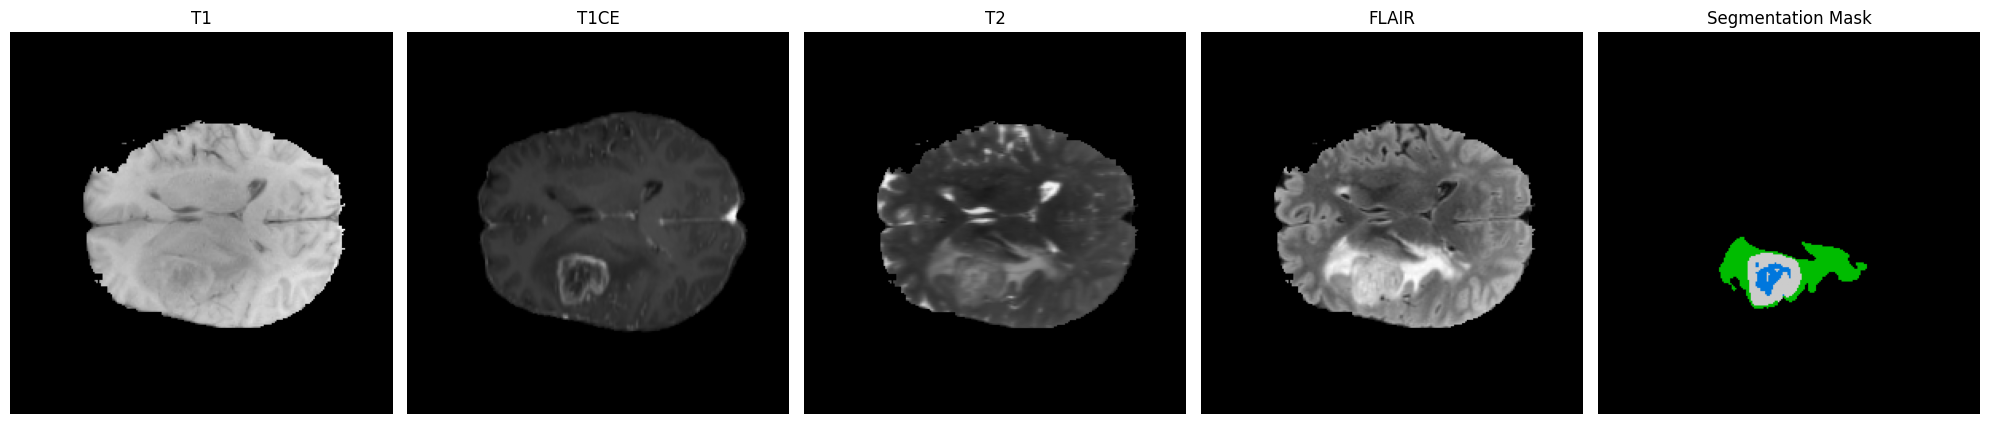

In [3]:
# --- STEP 3: VISUALIZATION (SILENT AUTO-SKIP) ---

import os
import glob
import matplotlib.pyplot as plt
import nibabel as nib
import warnings

# Suppress standard Python/nibabel warnings for a completely clean output
warnings.filterwarnings("ignore")

# Helper function
def find_mri_file(folder, modality):
    files = glob.glob(os.path.join(folder, f'*_{modality}.nii.gz'))
    if not files:
        files = glob.glob(os.path.join(folder, f'*_{modality}.nii'))
    if not files:
        raise FileNotFoundError()
    return files[0]

def load_scan(path):
    return nib.load(path).get_fdata()

# Loop through silently
for sample_patient_path in patient_folders:
    try:
        t1_path = find_mri_file(sample_patient_path, 't1')
        t1ce_path = find_mri_file(sample_patient_path, 't1ce')
        t2_path = find_mri_file(sample_patient_path, 't2')
        flair_path = find_mri_file(sample_patient_path, 'flair')
        seg_path = find_mri_file(sample_patient_path, 'seg')

        
        # Load the 3D scans
        t1 = load_scan(t1_path)
        t1ce = load_scan(t1ce_path)
        t2 = load_scan(t2_path)
        flair = load_scan(flair_path)
        seg = load_scan(seg_path)

        # If it makes it here without crashing, we found a good one!
        patient_id = os.path.basename(sample_patient_path)
        print(f"\n✔ Success! Visualizing patient: {patient_id}")
        print(f"✔ 3D Volume Shape: {t1.shape}")
        
        middle_slice = t1.shape[2] // 2
        print(f"✔ Showing slice number: {middle_slice}")

        # Plotting
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))

        axes[0].imshow(t1[:, :, middle_slice], cmap='gray')
        axes[0].set_title('T1')

        axes[1].imshow(t1ce[:, :, middle_slice], cmap='gray')
        axes[1].set_title('T1CE')

        axes[2].imshow(t2[:, :, middle_slice], cmap='gray')
        axes[2].set_title('T2')

        axes[3].imshow(flair[:, :, middle_slice], cmap='gray')
        axes[3].set_title('FLAIR')

        axes[4].imshow(seg[:, :, middle_slice], cmap='nipy_spectral')
        axes[4].set_title('Segmentation Mask')

        for ax in axes:
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        
        # Stop the loop! 
        break 

    except Exception:
        # Silently ignore the error and move to the next patient
        pass

In [4]:
def stack_modalities(t1_array, t1ce_array, t2_array, flair_array):
    """
    Combines 4 individual MRI modalities into a single 4-channel 3D volume.
    """

    stacked_volume = np.stack([t1_array, t1ce_array, t2_array, flair_array], axis=-1)

    return stacked_volume

patient_volume = stack_modalities(t1, t1ce, t2, flair)

print(f"✔ Single Modality Shape (H, W, D): {t1.shape}")
print(f"✔ Stacked Volume Shape (H, W, D, Channels): {patient_volume.shape}")

✔ Single Modality Shape (H, W, D): (240, 240, 155)
✔ Stacked Volume Shape (H, W, D, Channels): (240, 240, 155, 4)


In [5]:
# STEP 5: PREPROCESSING

print(f"✔ Unique values BEFORE processing: {np.unique(seg)}")


binary_mask = (seg > 0).astype(np.uint8)

print(f"✔ Unique values AFTER Binary processing: {np.unique(binary_mask)}")



multiclass_mask = np.copy(seg)

multiclass_mask[multiclass_mask == 4] = 3
multiclass_mask = multiclass_mask.astype(np.uint8)

print(f"✔ Unique values AFTER Multi-class processing: {np.unique(multiclass_mask)}")

✔ Unique values BEFORE processing: [0. 1. 2. 4.]
✔ Unique values AFTER Binary processing: [0 1]
✔ Unique values AFTER Multi-class processing: [0 1 2 3]


In [6]:
#STEP 6: RESIZE

from skimage.transform import resize

TARGET_SHAPE = (128, 128, 128)

def resize_image_volume(volume):
    """
    Resizes the 4-channel MRI volume.
    Target shape becomes (128, 128, 128, 4)
    """
    target_shape_with_channels = (TARGET_SHAPE[0], TARGET_SHAPE[1], TARGET_SHAPE[2], volume.shape[-1])
    resized_volume = resize(volume, target_shape_with_channels, mode='constant', anti_aliasing=True)
    return resized_volume

def resize_segmentation_mask(mask):
    """
    Resizes the 3D segmentation mask.
    Strictly uses nearest-neighbor interpolation (order=0) to preserve distinct class labels.
    """
    resized_mask = resize(mask, TARGET_SHAPE, order=0, mode='constant', anti_aliasing=False, preserve_range=True)
    return resized_mask

resized_patient_volume = resize_image_volume(patient_volume)

resized_mask = resize_segmentation_mask(multiclass_mask)

print("✔ BEFORE Resizing:")
print(f"  Volume shape: {patient_volume.shape}")
print(f"  Mask shape:   {multiclass_mask.shape}")

print("\n✔ AFTER Resizing:")
print(f"  Volume shape: {resized_patient_volume.shape}")
print(f"  Mask shape:   {resized_mask.shape}")

print(f"  Mask unique values: {np.unique(resized_mask)}")

✔ BEFORE Resizing:
  Volume shape: (240, 240, 155, 4)
  Mask shape:   (240, 240, 155)

✔ AFTER Resizing:
  Volume shape: (128, 128, 128, 4)
  Mask shape:   (128, 128, 128)
  Mask unique values: [0 1 2 3]


In [7]:
#STEP 7: NORMALIZATION

def min_max_normalize(volume):
    """
    Applies Min-Max normalization per modality (channel) to a 4D volume.
    Input shape expected: (H, W, D, Channels)
    """
    normalized_volume = np.zeros_like(volume, dtype=np.float32)

    for channel in range(volume.shape[-1]):
        modality_data = volume[:, :, :, channel]

        min_val = np.min(modality_data)
        max_val = np.max(modality_data)

        if max_val - min_val > 0:
            normalized_volume[:, :, :, channel] = (modality_data - min_val) / (max_val - min_val)
        else:
            normalized_volume[:, :, :, channel] = modality_data

    return normalized_volume

normalized_patient_volume = min_max_normalize(resized_patient_volume)

print("✔ BEFORE Normalization (Raw Intensity Ranges):")
for i, name in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
    print(f"  {name} Min: {np.min(resized_patient_volume[:,:,:,i]):.2f}, Max: {np.max(resized_patient_volume[:,:,:,i]):.2f}")

print("\n✔ AFTER Min-Max Normalization:")
for i, name in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
    print(f"  {name} Min: {np.min(normalized_patient_volume[:,:,:,i]):.2f}, Max: {np.max(normalized_patient_volume[:,:,:,i]):.2f}")

✔ BEFORE Normalization (Raw Intensity Ranges):
  T1 Min: 0.00, Max: 1512.87
  T1CE Min: 0.00, Max: 10606.72
  T2 Min: 0.00, Max: 1967.51
  FLAIR Min: 0.00, Max: 2861.70

✔ AFTER Min-Max Normalization:
  T1 Min: 0.00, Max: 1.00
  T1CE Min: 0.00, Max: 1.00
  T2 Min: 0.00, Max: 1.00
  FLAIR Min: 0.00, Max: 1.00


In [8]:
#STEP 8: TRAIN / VALIDATION SPLIT

train_patients, val_patients = train_test_split(patient_folders,
                                                test_size=0.20,
                                                random_state=42)

print(f"✔ Total patients: {len(patient_folders)}")
print(f"✔ Training patients (80%): {len(train_patients)}")
print(f"✔ Validation patients (20%): {len(val_patients)}")

✔ Total patients: 1251
✔ Training patients (80%): 1000
✔ Validation patients (20%): 251


In [9]:
print("Sample train patient:", os.path.basename(train_patients[0]))
print("Sample val patient:", os.path.basename(val_patients[0]))

Sample train patient: BraTS2021_00284
Sample val patient: BraTS2021_01137


In [10]:
# --- STEP 9: SILENT BULLETPROOF 3D DATA GENERATOR ---

import math
import glob
import os
import numpy as np
import nibabel as nib
from skimage.transform import resize
from tensorflow.keras.utils import Sequence, to_categorical
import warnings

# Suppress background warnings for a clean output
warnings.filterwarnings("ignore")

class BraTSDataGenerator(Sequence):
    def __init__(self, patient_paths, batch_size=1, target_shape=(128, 128, 128), num_classes=4, shuffle=True):
        self.patient_paths = patient_paths
        self.batch_size = batch_size
        self.target_shape = target_shape
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.patient_paths) / self.batch_size)
        
    def _find_mri_file(self, folder, modality):
        files = glob.glob(os.path.join(folder, f'*_{modality}.nii.gz'))
        if not files:
            files = glob.glob(os.path.join(folder, f'*_{modality}.nii'))
        if not files:
            raise FileNotFoundError()
        return files[0]

    def __getitem__(self, index):
        batch_paths = self.patient_paths[index * self.batch_size : (index + 1) * self.batch_size]

        X = np.empty((len(batch_paths), *self.target_shape, 4))
        Y = np.empty((len(batch_paths), *self.target_shape, self.num_classes))

        for i, path in enumerate(batch_paths):
            success = False
            current_path = path

            # 🛡️ SILENT FAULT TOLERANCE LOOP
            while not success:
                try:
                    t1_file = self._find_mri_file(current_path, 't1')
                    t1ce_file = self._find_mri_file(current_path, 't1ce')
                    t2_file = self._find_mri_file(current_path, 't2')
                    flair_file = self._find_mri_file(current_path, 'flair')
                    seg_file = self._find_mri_file(current_path, 'seg')

                    t1 = nib.load(t1_file).get_fdata()
                    t1ce = nib.load(t1ce_file).get_fdata()
                    t2 = nib.load(t2_file).get_fdata()
                    flair = nib.load(flair_file).get_fdata()
                    seg = nib.load(seg_file).get_fdata()

                    # Remap class 4 to 3
                    seg[seg == 4] = 3

                    stacked_vol = np.stack([t1, t1ce, t2, flair], axis=-1)
                    target_vol_shape = (*self.target_shape, 4)

                    # Resize volumes
                    resized_vol = resize(stacked_vol, target_vol_shape, mode='constant', anti_aliasing=True)
                    resized_seg = resize(seg, self.target_shape, order=0, mode='constant', anti_aliasing=False, preserve_range=True)

                    # Normalize
                    for c in range(4):
                        min_val, max_val = np.min(resized_vol[..., c]), np.max(resized_vol[..., c])
                        if max_val - min_val > 0:
                            resized_vol[..., c] = (resized_vol[..., c] - min_val) / (max_val - min_val)

                    encoded_seg = to_categorical(resized_seg, num_classes=self.num_classes)

                    X[i] = resized_vol
                    Y[i] = encoded_seg

                    success = True 
                    
                except Exception:
                    # Silently swap for a random healthy patient without disrupting the output
                    current_path = np.random.choice(self.patient_paths)

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.patient_paths)

# ==========================================
# INITIALIZE GENERATORS
# ==========================================
print("⚙️ Initializing Silent Data Generators...")
train_generator = BraTSDataGenerator(train_patients, batch_size=1)
val_generator = BraTSDataGenerator(val_patients, batch_size=1, shuffle=False)
print("✔ Generators ready!")

⚙️ Initializing Silent Data Generators...
✔ Generators ready!


In [11]:
# Step 10 --- 3. BUILD MODEL 1: 3D CNN AUTOENCODER (BATCH SIZE=1, 4 CLASSES) ---

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D, BatchNormalization, Activation

def build_3d_autoencoder(input_shape=(128, 128, 128, 4), num_classes=4, batch_size=1):
    """
    Constructs a 3D CNN Autoencoder locked to batch_size=1 with 4 output channels.
    """
    # Lock the batch size to 1 to match the generator and prevent memory crashes
    inputs = Input(shape=input_shape, batch_size=batch_size)

    # ==========================================
    # ENCODER
    # ==========================================

    # Block 1 (128 -> 64)
    x = Conv3D(16, (3, 3, 3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling3D(pool_size=(2, 2, 2))(x)

    # Block 2 (64 -> 32)
    x = Conv3D(32, (3, 3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling3D(pool_size=(2, 2, 2))(x)

    # Bottleneck
    x = Conv3D(64, (3, 3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # ==========================================
    # DECODER
    # ==========================================

    # Block 1 (32 -> 64)
    x = UpSampling3D(size=(2, 2, 2))(x)
    x = Conv3D(32, (3, 3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Block 2 (64 -> 128)
    x = UpSampling3D(size=(2, 2, 2))(x)
    x = Conv3D(16, (3, 3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # ==========================================
    # FINAL LAYER
    # ==========================================

    # filters=4 matches your 4 classes, activation='softmax' for multi-class prediction
    outputs = Conv3D(filters=num_classes, kernel_size=(1, 1, 1), activation='softmax')(x)

    # Instantiate the model
    model = Model(inputs=inputs, outputs=outputs, name="3D_Autoencoder_4_Class")

    return model

autoencoder_model = build_3d_autoencoder()

# Print the model summary
autoencoder_model.summary()

I0000 00:00:1774014952.754875      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774014952.760767      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "3D_Autoencoder_4_Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (1, 128, 128, 128, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (1, 128, 128, 128, 16) │         1,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 128, 128, 128, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (1, 128, 128, 128, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (1, 64, 64, 64, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (1, 64, 64, 64, 32)    │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 64, 64, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (1, 64, 64, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (1, 32, 32, 32, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (1, 32, 32, 32, 64)    │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 32, 32, 32, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (1, 32, 32, 32, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling3d (UpSampling3D)    │ (1, 64, 64, 64, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (1, 64, 64, 64, 32)    │        55,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 64, 64, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (1, 64, 64, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling3d_1 (UpSampling3D)  │ (1, 128, 128, 128, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_4 (Conv3D)               │ (1, 128, 128, 128, 16) │        13,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (1, 128, 128, 128, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (1, 128, 128, 128, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_5 (Conv3D)               │ (1, 128, 128, 128, 4)  │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140,836 (550.14 KB)

 Trainable params: 140,516 (548.89 KB)

 Non-trainable params: 320 (1.25 KB)

In [12]:
# Step 11. DEFINE LOSS FUNCTION & METRICS ---

import tensorflow as tf
import tensorflow.keras.backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Calculates the Dice Similarity Coefficient (metric).
    Casts tensors to float32 to prevent type mismatch errors between NumPy and Keras.
    """
    # Force both tensors to float32
    y_true = K.cast(y_true, 'float32')
    y_pred = K.cast(y_pred, 'float32')

    # Flatten the 3D arrays to 1D to easily compute the intersection
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Calculate the spatial overlap (intersection)
    intersection = K.sum(y_true_f * y_pred_f)

    # Calculate the Dice score
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """
    Computes the Dice Loss. The model will minimize this value to maximize the Dice Coefficient.
    """
    return 1.0 - dice_coefficient(y_true, y_pred)

print("✔ Custom Dice Loss defined!")
print("✔ Custom Dice Metric defined!")

✔ Custom Dice Loss defined!
✔ Custom Dice Metric defined!


In [13]:
# Step 12. COMPILE THE MODEL & DEFINE METRICS ---

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam

# 1. Define Custom Evaluation Metrics
def jaccard_coefficient(y_true, y_pred, smooth=1e-6):
    """Intersection over Union (IoU)"""
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(K.cast(y_pred, 'float32'))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def precision_m(y_true, y_pred, smooth=1e-6):
    """Positive Predictive Value"""
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(K.cast(y_pred, 'float32'))
    true_positives = K.sum(y_true_f * y_pred_f)
    predicted_positives = K.sum(y_pred_f)
    return (true_positives + smooth) / (predicted_positives + smooth)

def recall_m(y_true, y_pred, smooth=1e-6):
    """Sensitivity / True Positive Rate"""
    y_true_f = K.flatten(K.cast(y_true, 'float32'))
    y_pred_f = K.flatten(K.cast(y_pred, 'float32'))
    true_positives = K.sum(y_true_f * y_pred_f)
    possible_positives = K.sum(y_true_f)
    return (true_positives + smooth) / (possible_positives + smooth)

def f1_m(y_true, y_pred):
    """F1-Score is mathematically equivalent to the Dice Coefficient in segmentation"""
    return dice_coefficient(y_true, y_pred)

# 2. Initialize the Optimizer
# A learning rate of 1e-4 is highly recommended to keep the 3D model stable
optimizer = Adam(learning_rate=0.0001)

# 3. Compile the Model
autoencoder_model.compile(
    optimizer=optimizer,
    loss=dice_loss,                 # Custom loss from Step 4
    metrics=[
        'accuracy',                 # Standard Keras accuracy
        dice_coefficient,
        jaccard_coefficient,
        f1_m,
        precision_m,
        recall_m
    ]
)

print("✔ All custom metrics loaded (Dice, Jaccard, F1, Precision, Recall, Accuracy).")
print("✔ Model successfully compiled and ready for training!")

✔ All custom metrics loaded (Dice, Jaccard, F1, Precision, Recall, Accuracy).
✔ Model successfully compiled and ready for training!


In [14]:
### STEP 13: MODEL TRAINING ---

import math
import glob
import os
import numpy as np
import nibabel as nib
from skimage.transform import resize
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import warnings

# ==========================================
# 3. SET UP CALLBACKS & TRAIN
# ==========================================
print("\n🚀 Starting 3D Autoencoder Training (Batch Size = 1)...")
print("☕ Grab a coffee! Processing 3D volumes takes time.")

checkpoint = ModelCheckpoint(
    filepath='best_3d_autoencoder.keras',
    monitor='val_dice_coefficient',     
    mode='max',                         
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 6

# Execute the Training Loop
history = autoencoder_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

print("✅ Training Complete! Your best model weights are safely saved.")


🚀 Starting 3D Autoencoder Training (Batch Size = 1)...
☕ Grab a coffee! Processing 3D volumes takes time.
Epoch 1/6


I0000 00:00:1774014970.978657     128 service.cc:152] XLA service 0x7a272c21ab60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774014970.978694     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774014970.978714     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774014971.787490     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-20 13:56:12.780452: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:56:12.916405: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:56:13.058647: E external/local_xl

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9065 - dice_coefficient: 0.5567 - f1_m: 0.5567 - jaccard_coefficient: 0.3972 - loss: 0.4433 - precision_m: 0.5567 - recall_m: 0.5567
Epoch 1: val_dice_coefficient improved from -inf to 0.74945, saving model to best_3d_autoencoder.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5278s 5s/step - accuracy: 0.9065 - dice_coefficient: 0.5569 - f1_m: 0.5569 - jaccard_coefficient: 0.3973 - loss: 0.4431 - precision_m: 0.5569 - recall_m: 0.5569 - val_accuracy: 0.9708 - val_dice_coefficient: 0.7494 - val_f1_m: 0.7494 - val_jaccard_coefficient: 0.6007 - val_loss: 0.2506 - val_precision_m: 0.7494 - val_recall_m: 0.7494
Epoch 2/6
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9909 - dice_coefficient: 0.8734 - f1_m: 0.8734 - jaccard_coefficient: 0.7764 - loss: 0.1266 - precision_m: 0.8734 - recall_m: 0.8734
Epoch 2: val_dice_coefficient improved from 0.74945 to 0.92061, saving model to best_3d_autoencoder.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5492s

✅ Dashboard successfully saved to /kaggle/working/training_metrics_dashboard.png


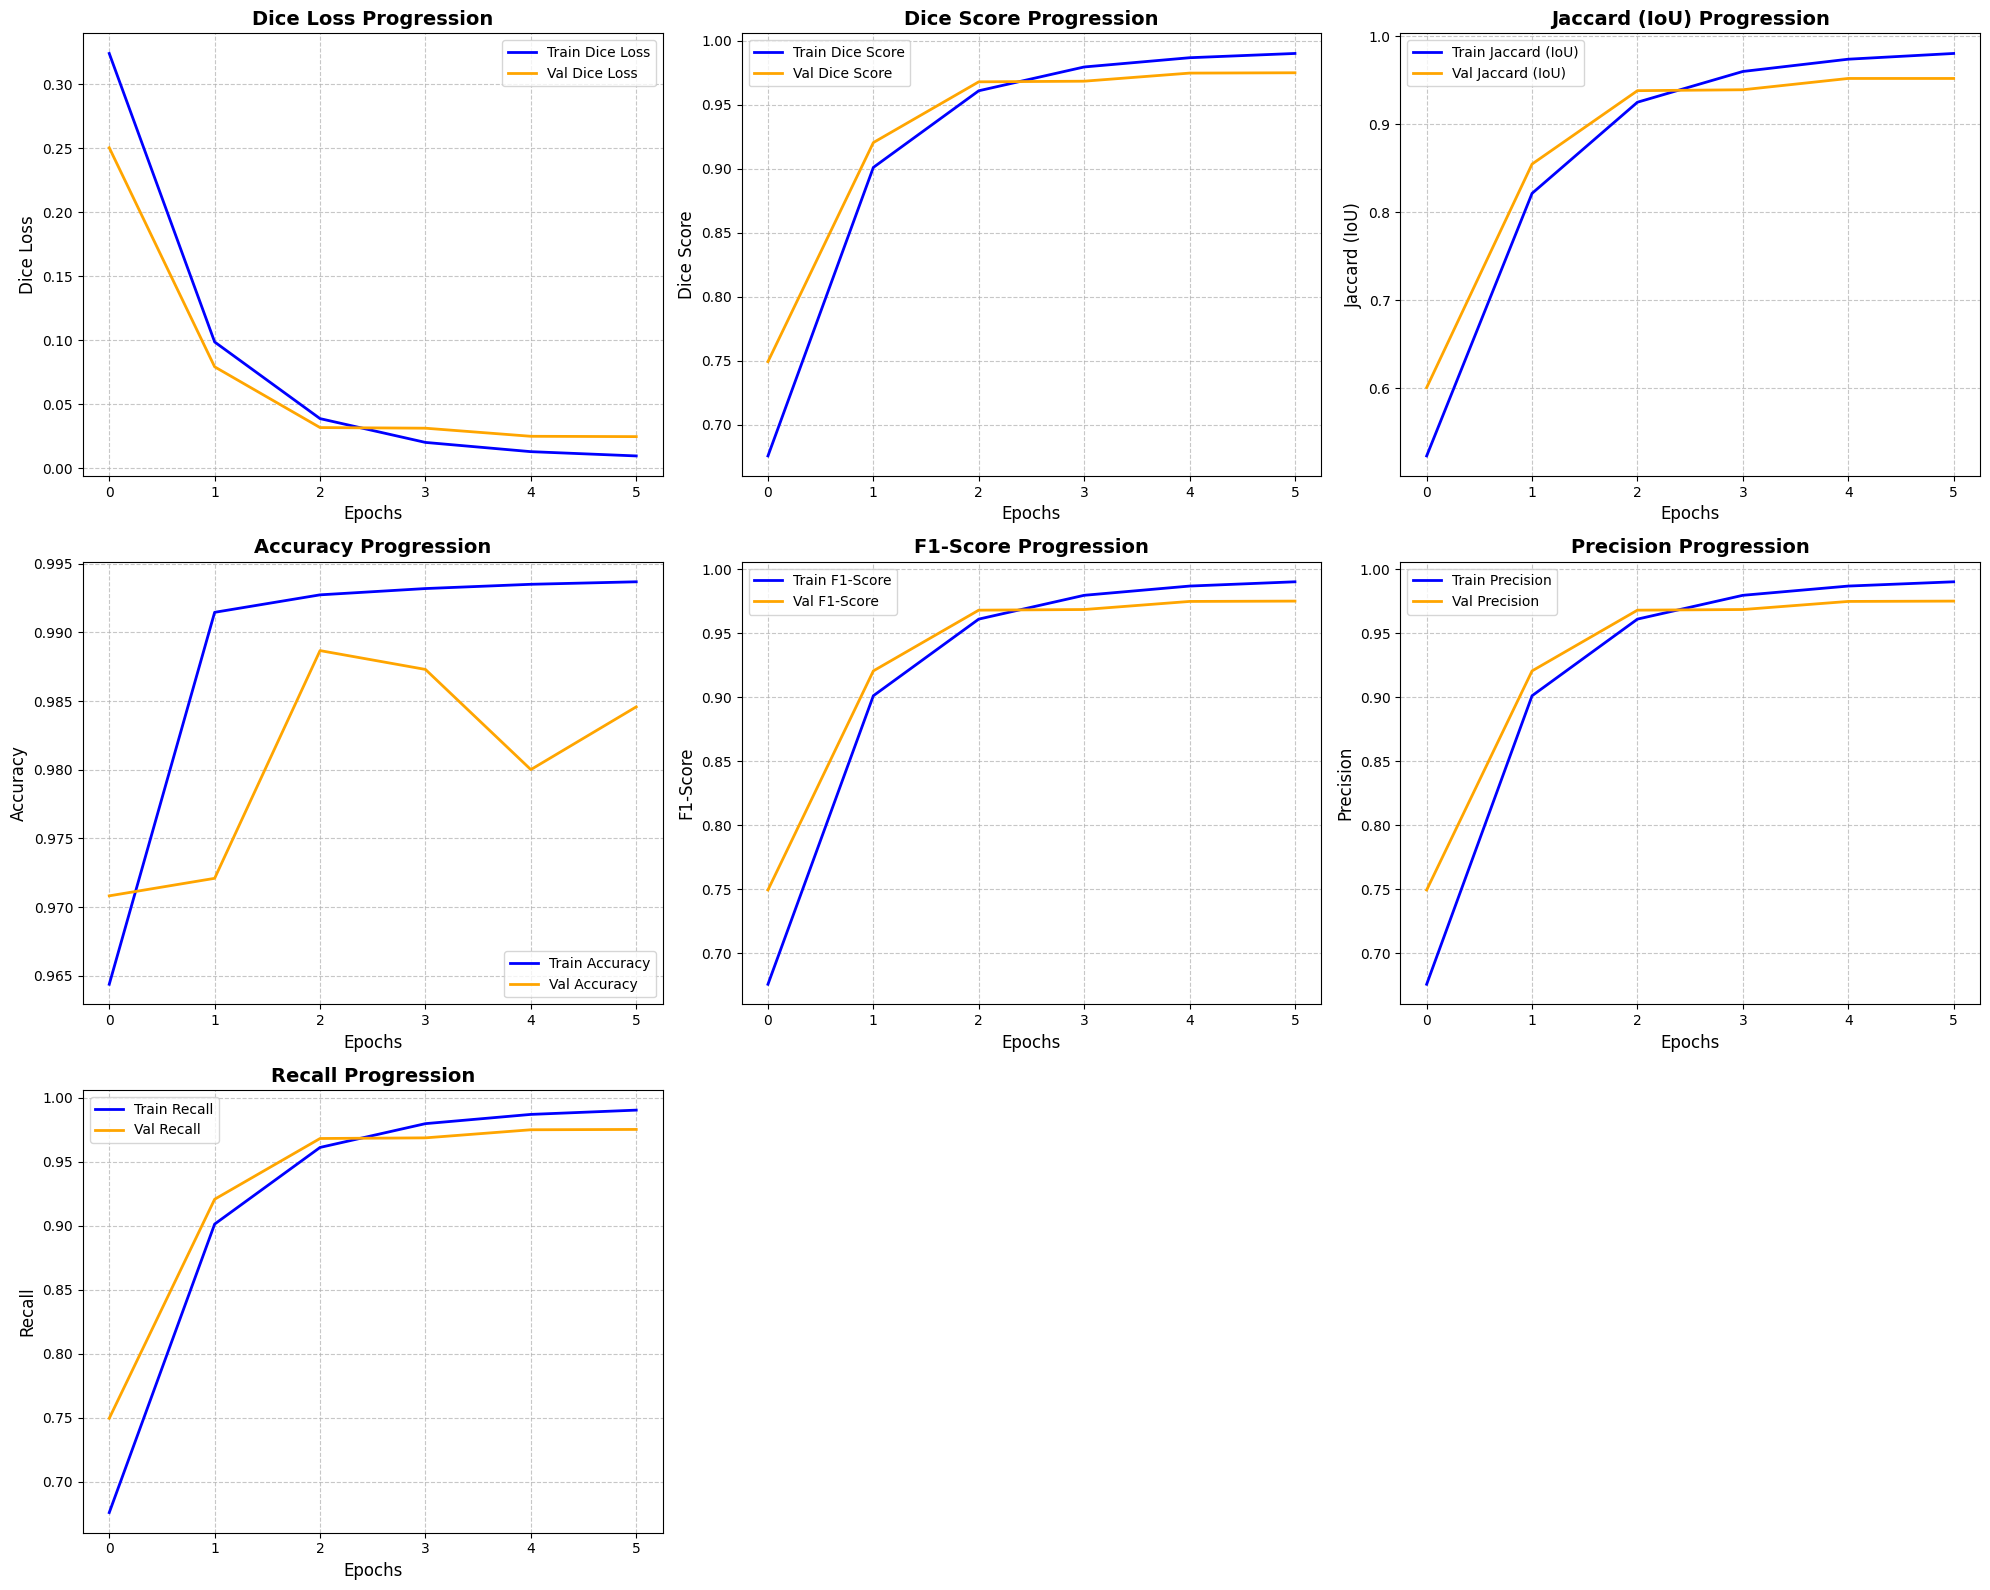

In [15]:
# --- STEP 14: PLOT & SAVE ALL TRAINING RESULTS ---

import matplotlib.pyplot as plt

# A dictionary mapping the exact Keras history keys to clean presentation labels
metrics_to_plot = {
    'loss': 'Dice Loss',
    'dice_coefficient': 'Dice Score',
    'jaccard_coefficient': 'Jaccard (IoU)',
    'accuracy': 'Accuracy',
    'f1_m': 'F1-Score',
    'precision_m': 'Precision',
    'recall_m': 'Recall'
}

# Create a large, high-resolution figure perfect for a presentation slide
plt.figure(figsize=(20, 16))

# Loop through the metrics and create a subplot for each one
for i, (metric_key, metric_title) in enumerate(metrics_to_plot.items(), 1):
    plt.subplot(3, 3, i)

    # Plot Training Data
    plt.plot(history.history[metric_key],
             label=f'Train {metric_title}',
             color='blue',
             linewidth=2)

    # Plot Validation Data
    plt.plot(history.history[f'val_{metric_key}'],
             label=f'Val {metric_title}',
             color='orange',
             linewidth=2)

    # Formatting
    plt.title(f'{metric_title} Progression', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel(metric_title, fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout so the titles don't overlap
plt.tight_layout()

# 📸 NEW: Save a high-resolution copy for your project presentation!
plt.savefig('/kaggle/working/training_metrics_dashboard.png', dpi=300, bbox_inches='tight')
print("✅ Dashboard successfully saved to /kaggle/working/training_metrics_dashboard.png")

# Display the final dashboard
plt.show()

Input MRI Volume Shape: (1, 128, 128, 128, 4) -> (batch, H, W, D, modalities)
True Label Shape: (1, 128, 128, 128, 4) -> (batch, H, W, D, one-hot classes)

🤖 Running prediction on unseen patient volume...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✔ Final Predicted Mask Shape: (1, 128, 128, 128)
✔ Final Ground Truth Mask Shape: (1, 128, 128, 128)

📸 Visualizing Z-Slice 28 (Slice with maximum tumor presence)
✅ Visualization saved to /kaggle/working/prediction_comparison.png


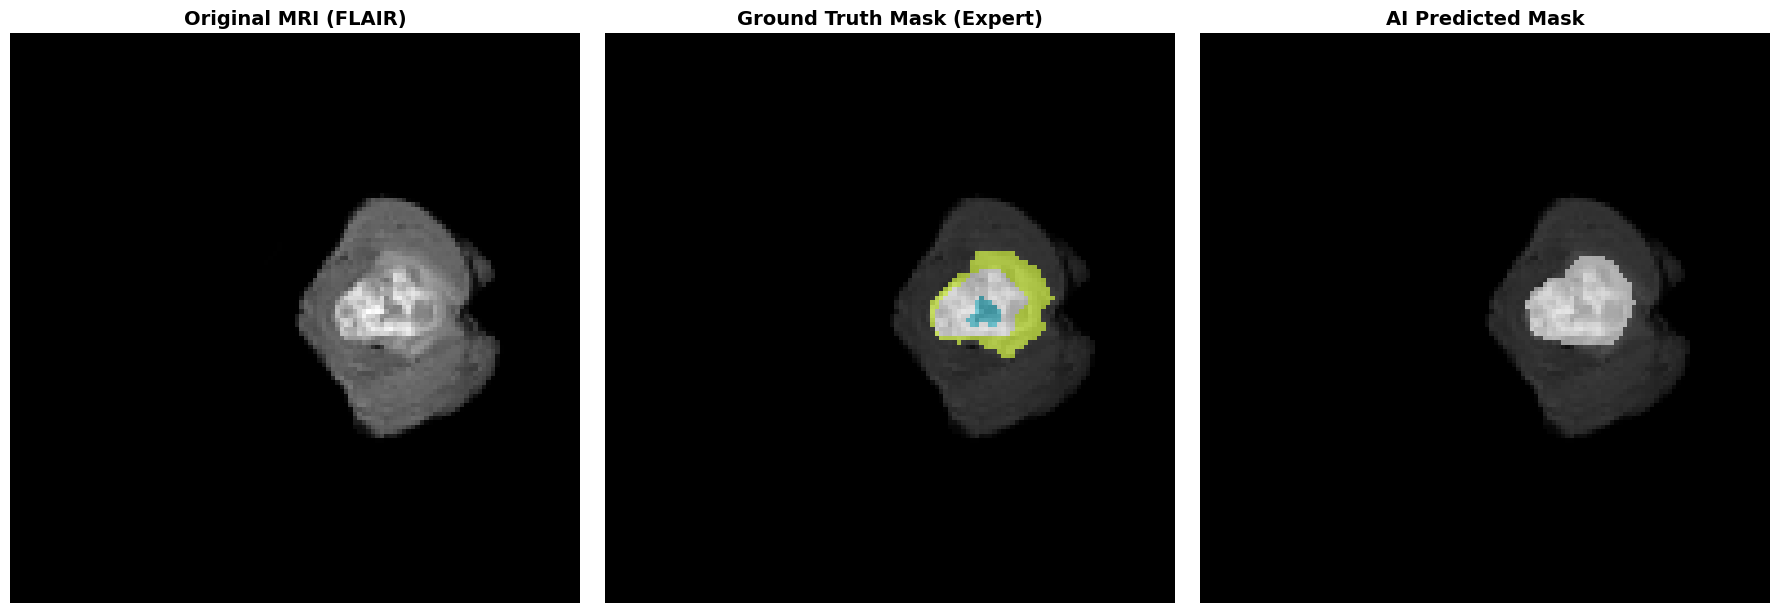

In [16]:
# --- STEP 15: PREDICT & VISUALIZE TUMOR SEGMENTATION ---

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. RUN PREDICTION
# ==========================================
X_val, Y_val_true = val_generator[0]

print(f"Input MRI Volume Shape: {X_val.shape} -> (batch, H, W, D, modalities)")
print(f"True Label Shape: {Y_val_true.shape} -> (batch, H, W, D, one-hot classes)")

print("\n🤖 Running prediction on unseen patient volume...")
prediction_probs = autoencoder_model.predict(X_val)

# Convert one-hot to single integer masks (0, 1, 2, 3)
predicted_mask = np.argmax(prediction_probs, axis=-1)
ground_truth_mask = np.argmax(Y_val_true, axis=-1)

print(f"✔ Final Predicted Mask Shape: {predicted_mask.shape}")
print(f"✔ Final Ground Truth Mask Shape: {ground_truth_mask.shape}")

# ==========================================
# 2. SMART VISUALIZATION
# ==========================================
# Extract the first patient in the batch
patient_flair = X_val[0, ..., 3]  # Index 3 is FLAIR (T1=0, T1ce=1, T2=2, FLAIR=3)
patient_gt = ground_truth_mask[0]
patient_pred = predicted_mask[0]

# SMART SLICE SELECTOR: Find the slice with the maximum tumor area
# We sum the pixels > 0 along the X and Y axes to find the Z-slice with the most tumor
tumor_areas_per_slice = np.sum(patient_gt > 0, axis=(0, 1))
best_slice_idx = np.argmax(tumor_areas_per_slice)

print(f"\n📸 Visualizing Z-Slice {best_slice_idx} (Slice with maximum tumor presence)")

# Plot the results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original FLAIR MRI
axes[0].imshow(patient_flair[:, :, best_slice_idx], cmap='gray')
axes[0].set_title('Original MRI (FLAIR)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Ground Truth Mask (What the doctor drew)
axes[1].imshow(patient_flair[:, :, best_slice_idx], cmap='gray') # Background
axes[1].imshow(patient_gt[:, :, best_slice_idx], cmap='nipy_spectral', alpha=0.5) # Overlay
axes[1].set_title('Ground Truth Mask (Expert)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Predicted Mask (What your AI drew)
axes[2].imshow(patient_flair[:, :, best_slice_idx], cmap='gray') # Background
axes[2].imshow(patient_pred[:, :, best_slice_idx], cmap='nipy_spectral', alpha=0.5) # Overlay
axes[2].set_title('AI Predicted Mask', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()

# Save for your presentation!
plt.savefig('/kaggle/working/prediction_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved to /kaggle/working/prediction_comparison.png")

plt.show()

✅ Multi-slice dashboard saved to /kaggle/working/multi_slice_predictions.png


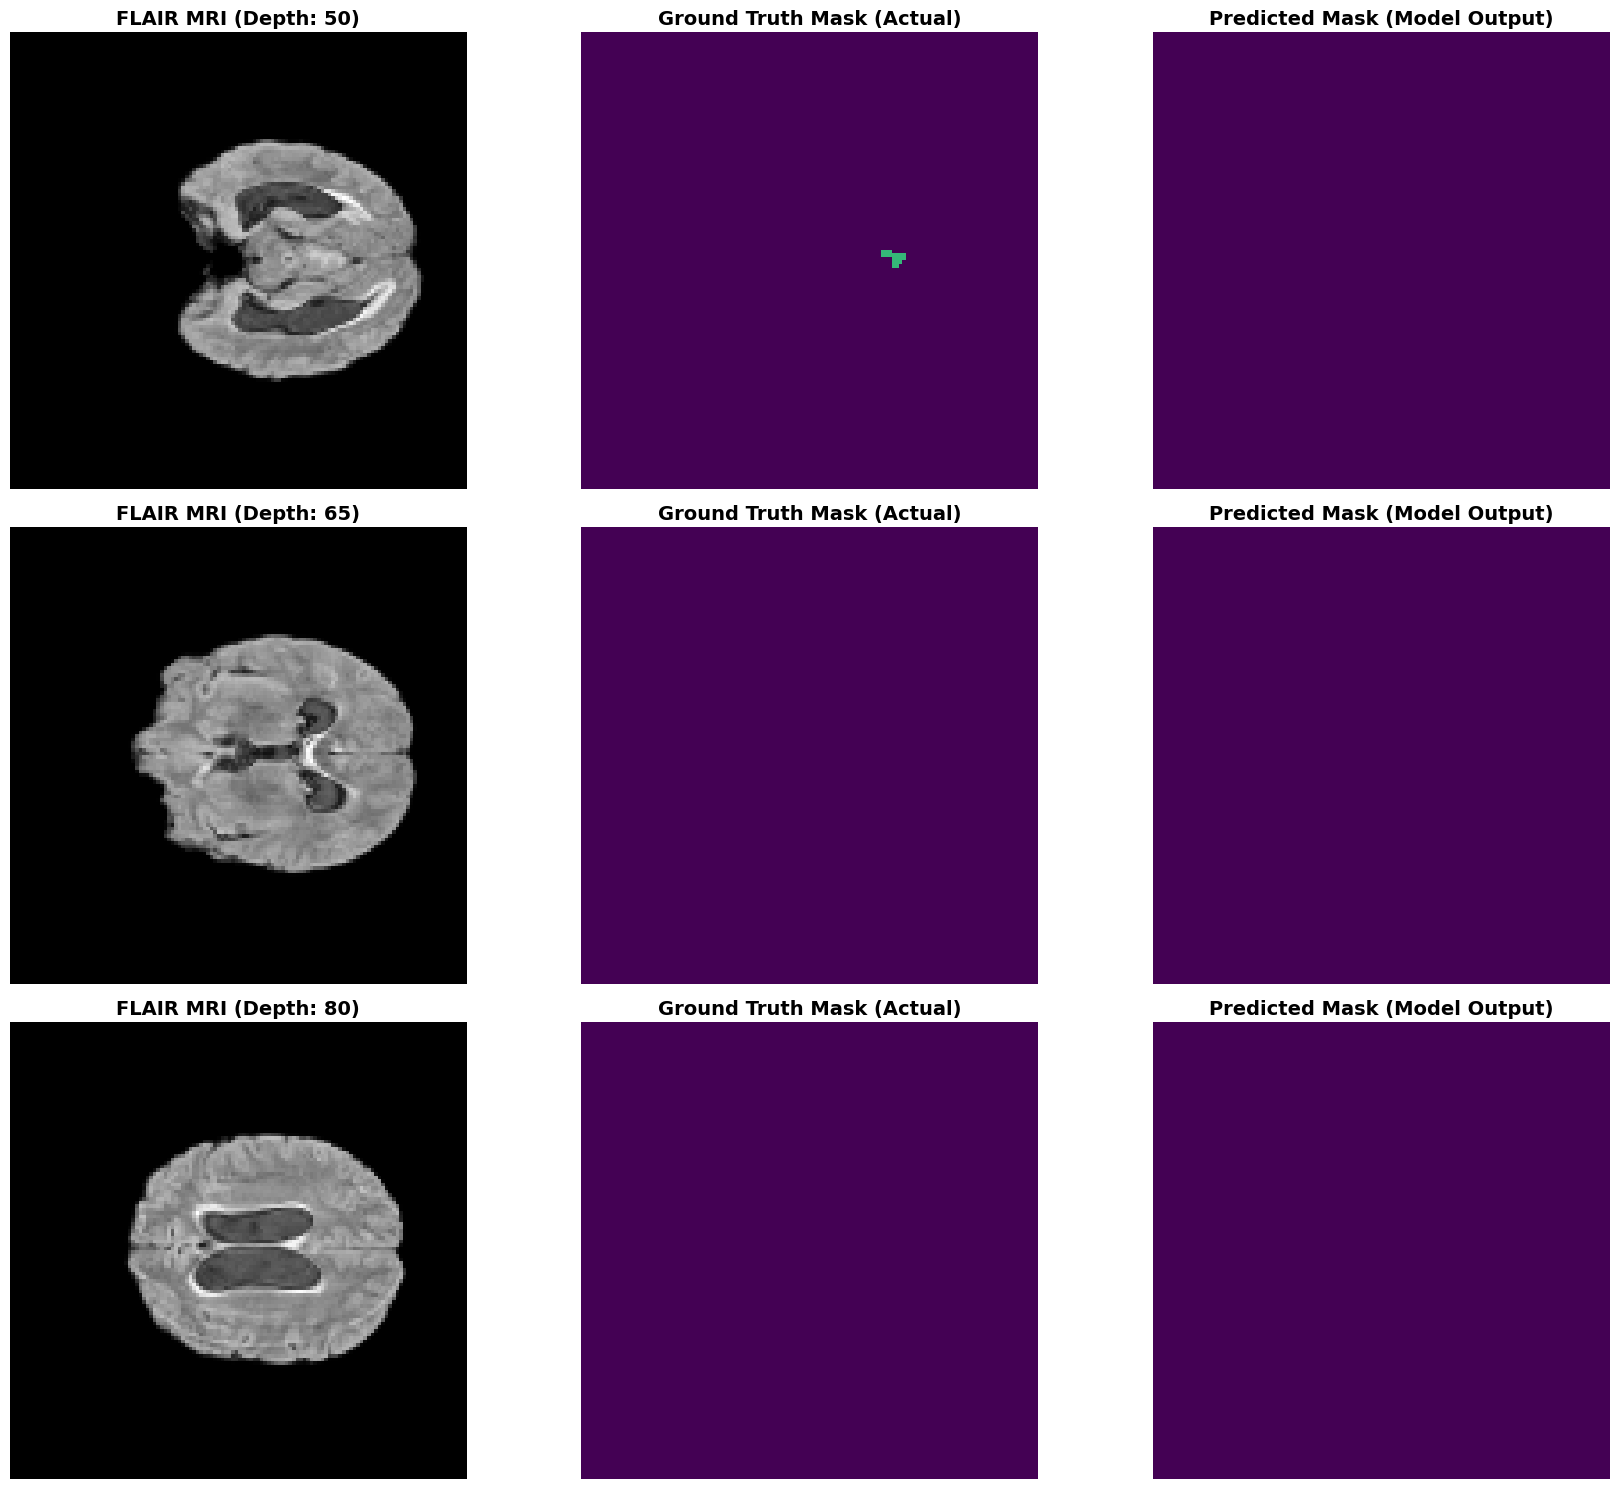

In [17]:
# --- STEP 16: 3D VOLUME SLICE DASHBOARD ---

import matplotlib.pyplot as plt

# 1. Choose three different depths to view how the tumor changes in 3D space
slices_to_view = [50, 65, 80]

# Create a large grid: 3 Rows (Depths) x 3 Columns (MRI, Truth, Prediction)
fig, axes = plt.subplots(len(slices_to_view), 3, figsize=(18, 15))

for i, slice_idx in enumerate(slices_to_view):
    
    # 2. Extract the 2D slices from the 3D arrays
    # Channel 3 is FLAIR
    mri_slice = X_val[0, :, :, slice_idx, 3]
    gt_slice = ground_truth_mask[0, :, :, slice_idx]
    pred_slice = predicted_mask[0, :, :, slice_idx]

    # 1️⃣ Original MRI Slice (FLAIR)
    axes[i, 0].imshow(mri_slice, cmap='gray')
    axes[i, 0].set_title(f"FLAIR MRI (Depth: {slice_idx})", fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')

    # 2️⃣ Ground Truth Mask
    # vmin=0, vmax=3 ensures the colors stay consistent across all slices
    axes[i, 1].imshow(gt_slice, cmap='viridis', interpolation='nearest', vmin=0, vmax=3)
    axes[i, 1].set_title("Ground Truth Mask (Actual)", fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')

    # 3️⃣ Predicted Mask
    axes[i, 2].imshow(pred_slice, cmap='viridis', interpolation='nearest', vmin=0, vmax=3)
    axes[i, 2].set_title("Predicted Mask (Model Output)", fontsize=14, fontweight='bold')
    axes[i, 2].axis('off')

# Render the plot neatly
plt.tight_layout()

# 📸 Save a high-resolution copy for your final report!
plt.savefig('/kaggle/working/multi_slice_predictions.png', dpi=300, bbox_inches='tight')
print("✅ Multi-slice dashboard saved to /kaggle/working/multi_slice_predictions.png")

plt.show()

In [25]:
# --- STEP 17: FINAL QUANTITATIVE EVALUATION (FULL DATASET) ---


# 1. Evaluate the model and tell Keras to return a dictionary directly!
metrics_dict = autoencoder_model.evaluate(val_generator, verbose=1, return_dict=True)

print("\n==========================================")
print("🏆 FINAL OVERALL MODEL PERFORMANCE")
print("==========================================")
# The keys might have 'val_' attached or exactly match the progress bar names. 
# We use .get() to check both just in case!
print(f"🔹 Dice Score:          {metrics_dict.get('dice_coefficient', metrics_dict.get('val_dice_coefficient', 0)):.4f}")
print(f"🔹 Jaccard (IoU):       {metrics_dict.get('jaccard_coefficient', metrics_dict.get('val_jaccard_coefficient', 0)):.4f}")
print(f"🔹 F1-Score:            {metrics_dict.get('f1_m', metrics_dict.get('val_f1_m', 0)):.4f}")
print(f"🔹 Precision:           {metrics_dict.get('precision_m', metrics_dict.get('val_precision_m', 0)):.4f}")
print(f"🔹 Recall:              {metrics_dict.get('recall_m', metrics_dict.get('val_recall_m', 0)):.4f}")
print(f"🔹 Pixel Accuracy:      {metrics_dict.get('accuracy', metrics_dict.get('val_accuracy', 0)):.4f}")
print(f"🔹 Dice Loss:           {metrics_dict.get('loss', metrics_dict.get('val_loss', 0)):.4f}")
print("==========================================\n")

251/251 ━━━━━━━━━━━━━━━━━━━━ 908s 4s/step - accuracy: 0.9841 - dice_coefficient: 0.9747 - f1_m: 0.9747 - jaccard_coefficient: 0.9516 - loss: 0.0253 - precision_m: 0.9747 - recall_m: 0.9747

🏆 FINAL OVERALL MODEL PERFORMANCE
🔹 Dice Score:          0.9764
🔹 Jaccard (IoU):       0.9546
🔹 F1-Score:            0.9764
🔹 Precision:           0.9764
🔹 Recall:              0.9764
🔹 Pixel Accuracy:      0.9858
🔹 Dice Loss:           0.0236



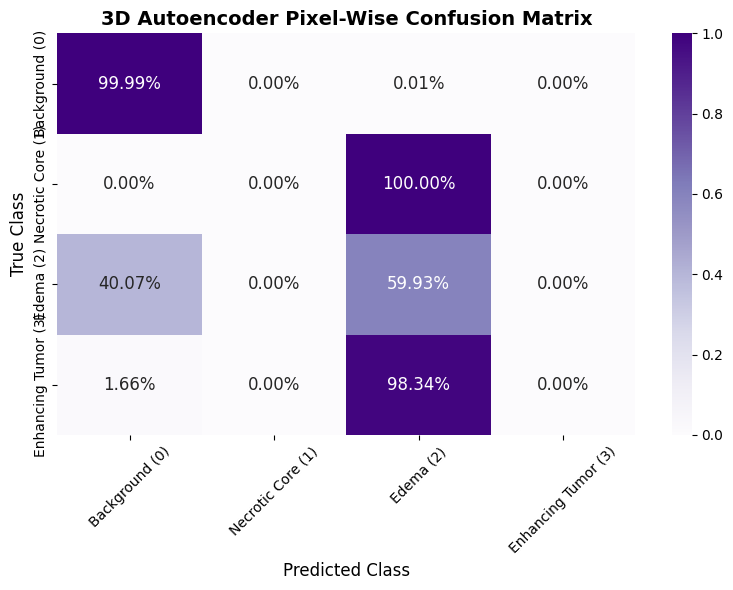

In [26]:
# --- STEP 17B: 3D SEGMENTATION CONFUSION MATRIX (PIXEL-WISE) ---

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# 1. Grab a single patient from the validation generator
# (Doing this for the entire dataset at once would crash Kaggle's RAM!)
X_val_sample, Y_val_sample = val_generator[0]

# 2. Generate Prediction for this 3D volume
pred_prob_sample = autoencoder_model.predict(X_val_sample, verbose=0)

# 3. Convert the one-hot probabilities back to single integer classes (0, 1, 2, 3)
y_true_classes = np.argmax(Y_val_sample, axis=-1)
y_pred_classes = np.argmax(pred_prob_sample, axis=-1)

# 4. THE FLATTEN STEP: Collapse the 3D arrays into 1D arrays
y_true_flat = y_true_classes.flatten()
y_pred_flat = y_pred_classes.flatten()

# 5. Calculate the Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2, 3])

# 6. THE NORMALIZATION STEP
# We divide each row by its sum so we get percentages. 
# np.nan_to_num prevents crashes if a specific tumor class is missing in this patient.
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percentage = np.nan_to_num(cm_percentage) 

# 7. Plot the Heatmap
plt.figure(figsize=(8, 6))

# The actual standard BraTS names for classes 0, 1, 2, 3
class_names = ['Background (0)', 'Necrotic Core (1)', 'Edema (2)', 'Enhancing Tumor (3)']

# We use fmt='.2%' to format the decimals as beautiful percentages (e.g. 95.40%)
sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 12})

plt.title('3D Autoencoder Pixel-Wise Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45) # Rotate labels slightly so they don't overlap
plt.tight_layout()

# 📸 Save a high-resolution copy for your final report!
plt.savefig('/kaggle/working/3d_segmentation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# --- Step 19A. CONVERT MRI VOLUMES TO 2D SLICES (BALANCED & BULLETPROOF) ---

import numpy as np
import glob
import os
import nibabel as nib
from skimage.transform import resize
import warnings

warnings.filterwarnings("ignore")

def extract_balanced_2d_dataset(patient_paths, target_shape=(224, 224)):
    """
    Extracts TWO 2D slices from each 3D MRI volume:
    - 1 slice containing a tumor (Class 1)
    - 1 healthy slice with no tumor (Class 0)
    This ensures a perfectly balanced dataset for EfficientNet!
    """
    print(f"Extracting 2D slices from {len(patient_paths)} patients...")
    X_2d = []
    Y_2d = []

    # Helper function to prevent Kaggle crashes
    def find_mri_file(folder, modality):
        files = glob.glob(os.path.join(folder, f'*_{modality}.nii.gz'))
        if not files:
            files = glob.glob(os.path.join(folder, f'*_{modality}.nii'))
        if not files:
            raise FileNotFoundError()
        return files[0]

    for path in patient_paths:
        try:
            t1ce_file = find_mri_file(path, 't1ce')
            t2_file = find_mri_file(path, 't2')
            flair_file = find_mri_file(path, 'flair')
            seg_file = find_mri_file(path, 'seg')

            # Load full 3D volumes
            t1ce_vol = nib.load(t1ce_file).get_fdata()
            t2_vol = nib.load(t2_file).get_fdata()
            flair_vol = nib.load(flair_file).get_fdata()
            seg_vol = nib.load(seg_file).get_fdata()

            # --- SMART SLICE SELECTION ---
            # 1. Find the slice with the MAXIMUM tumor presence
            tumor_areas = np.sum(seg_vol > 0, axis=(0, 1))
            tumor_slice_idx = np.argmax(tumor_areas)
            
            # 2. Find a completely CLEAN slice (usually near the top of the head)
            # We look for a slice where tumor area == 0, but still has brain tissue in the FLAIR scan
            brain_areas = np.sum(flair_vol > 0, axis=(0, 1))
            clean_candidates = np.where((tumor_areas == 0) & (brain_areas > 1000))[0]
            
            # If we can't find a clean slice, skip this patient to maintain perfect balance
            if len(clean_candidates) == 0 or tumor_areas[tumor_slice_idx] == 0:
                continue
                
            clean_slice_idx = clean_candidates[len(clean_candidates) // 2] # Grab a clean slice from the middle of the candidates

            # --- EXTRACT & PROCESS BOTH SLICES ---
            for slice_idx, label in [(tumor_slice_idx, 1), (clean_slice_idx, 0)]:
                
                t1ce_slice = t1ce_vol[:, :, slice_idx]
                t2_slice = t2_vol[:, :, slice_idx]
                flair_slice = flair_vol[:, :, slice_idx]

                # Stack into 3 channels (mimicking RGB)
                rgb_slice = np.stack([t1ce_slice, t2_slice, flair_slice], axis=-1)

                # Resize to 224x224
                resized_slice = resize(rgb_slice, (*target_shape, 3), mode='constant', anti_aliasing=True)

                # Normalize to [0, 1] per channel
                for c in range(3):
                    min_val, max_val = np.min(resized_slice[..., c]), np.max(resized_slice[..., c])
                    if max_val - min_val > 0:
                        resized_slice[..., c] = (resized_slice[..., c] - min_val) / (max_val - min_val)

                X_2d.append(resized_slice)
                Y_2d.append(label)

        except Exception:
            # Silently skip any corrupted patient folders
            continue

    return np.array(X_2d, dtype=np.float32), np.array(Y_2d, dtype=np.float32)

# ==========================================
# EXECUTE EXTRACTION
# ==========================================
print("⏳ Processing Training Set (This will take a few minutes)...")
X_train_2d, Y_train_2d = extract_balanced_2d_dataset(train_patients)

print("\n⏳ Processing Validation Set...")
X_val_2d, Y_val_2d = extract_balanced_2d_dataset(val_patients)

print("\n==========================================")
print(f"✔ 2D Training Data Shape:   {X_train_2d.shape}")
print(f"✔ 2D Training Labels Shape: {Y_train_2d.shape}")
print(f"✔ 2D Validation Data Shape: {X_val_2d.shape}")
print(f"✔ Total Positives (Tumor):  {int(np.sum(Y_train_2d) + np.sum(Y_val_2d))}")
print(f"✔ Total Negatives (Clean):  {int(len(Y_train_2d) - np.sum(Y_train_2d) + len(Y_val_2d) - np.sum(Y_val_2d))}")
print("==========================================")

⏳ Processing Training Set (This will take a few minutes)...
Extracting 2D slices from 1000 patients...

⏳ Processing Validation Set...
Extracting 2D slices from 251 patients...

✔ 2D Training Data Shape:   (1276, 224, 224, 3)
✔ 2D Training Labels Shape: (1276,)
✔ 2D Validation Data Shape: (318, 224, 224, 3)
✔ Total Positives (Tumor):  797
✔ Total Negatives (Clean):  797


In [21]:
# --- Step 19B. BUILD MODEL 2: EFFICIENTNET-B0 (SCALED) ---

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Rescaling

def build_efficientnet_classifier(input_shape=(224, 224, 3)):
    """
    Builds an EfficientNet-B0 model for binary tumor classification.
    """
    # 0. Define the input explicitly
    inputs = Input(shape=input_shape)
    
    # 1. THE SCALING FIX: EfficientNet expects [0, 255] inputs!
    # Multiply our [0, 1] data by 255 so EfficientNet's internal layers work correctly.
    scaled_inputs = Rescaling(255.0)(inputs)

    # 2. Load the pre-trained EfficientNetB0 without the top classification layer
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_tensor=scaled_inputs # Connect our scaled inputs directly to the base model
    )

    # Freeze the base model weights so we don't destroy the ImageNet features
    base_model.trainable = False

    # 3. Add custom classification layers on top
    x = base_model.output
    # GlobalAveragePooling converts the 2D feature maps into a 1D vector
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x) # Add dropout to prevent overfitting

    # 4. Final Output Layer: 1 node with sigmoid for binary classification (Tumor / No Tumor)
    outputs = Dense(1, activation='sigmoid')(x)

    # 5. Combine into a single model
    model = Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_Classifier")

    return model

# Instantiate the model
classifier_model = build_efficientnet_classifier()

# Print the summary
classifier_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_2[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
# --- Step 20A. COMPILE & TRAIN EFFICIENTNET ---

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Compile for binary classification
classifier_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training EfficientNet-B0 Classifier...")

# 2. Set up Callbacks
checkpoint_eff = ModelCheckpoint(
    filepath='/kaggle/working/best_efficientnet_classifier.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_eff = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=3, # If accuracy doesn't improve for 3 epochs, stop early
    restore_best_weights=True,
    verbose=1
)

# 3. Train the model
history_eff = classifier_model.fit(
    X_train_2d,
    Y_train_2d,
    validation_data=(X_val_2d, Y_val_2d),
    epochs=10,
    batch_size=32, # Standard batch size for 2D images
    callbacks=[checkpoint_eff, early_stopping_eff],
    verbose=1
)

print("✅ EfficientNet Training Complete! Best weights safely saved.")

🚀 Training EfficientNet-B0 Classifier...
Epoch 1/10


2026-03-20 23:23:04.122243: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:04.266054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:04.606520: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:04.746843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:05.451246: E external/local_xla/xla/stream_

39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7456 - loss: 0.5634

2026-03-20 23:23:20.533167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:20.675498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:21.010956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:21.151439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:21.868529: E external/local_xla/xla/stream_

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.7467 - loss: 0.5620

2026-03-20 23:23:40.549285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:40.692104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:41.025016: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:41.164979: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 23:23:41.860883: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.86478, saving model to /kaggle/working/best_efficientnet_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 61s 865ms/step - accuracy: 0.7478 - loss: 0.5607 - val_accuracy: 0.8648 - val_loss: 0.3789
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8533 - loss: 0.3954
Epoch 2: val_accuracy improved from 0.86478 to 0.89308, saving model to /kaggle/working/best_efficientnet_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.8535 - loss: 0.3950 - val_accuracy: 0.8931 - val_loss: 0.3264
Epoch 3/10
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8602 - loss: 0.3466
Epoch 3: val_accuracy improved from 0.89308 to 0.91195, saving model to /kaggle/working/best_efficientnet_classifier.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8612 - loss: 0.3456 - val_accuracy: 0.9119 - val_loss: 0.2829
Epoch 4/10
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9040 - loss: 0.2878
Epoch 4: val_accuracy did no

📊 Evaluating EfficientNet-B0 on Validation Data...

--- 2D CLASSIFICATION METRICS ---
🔹 Accuracy:      0.9214
🔹 Precision:     0.9136
🔹 Recall:        0.9308
🔹 F1 (Dice):     0.9221
🔹 Jaccard:       0.8555

✅ Confusion Matrix saved to /kaggle/working/efficientnet_confusion_matrix.png


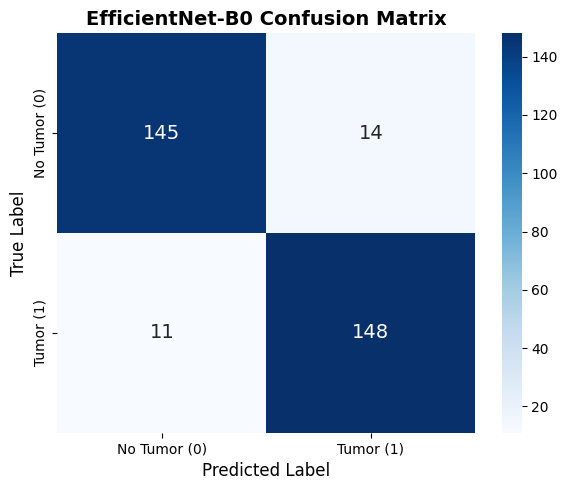

In [23]:
# --- Step 20B. EVALUATE & CONFUSION MATRIX ---

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix

print("📊 Evaluating EfficientNet-B0 on Validation Data...\n")

# 1. Generate Predictions
# The model outputs probabilities (e.g., 0.8), so we round them to 0 or 1
predictions_prob = classifier_model.predict(X_val_2d, verbose=0)
predictions_binary = (predictions_prob > 0.5).astype(int)

# 2. Calculate Metrics using Scikit-Learn
acc = accuracy_score(Y_val_2d, predictions_binary)
prec = precision_score(Y_val_2d, predictions_binary, zero_division=0)
rec = recall_score(Y_val_2d, predictions_binary, zero_division=0)
f1 = f1_score(Y_val_2d, predictions_binary, zero_division=0) # Equivalent to Dice
jaccard = jaccard_score(Y_val_2d, predictions_binary, zero_division=0)

# Print the results beautifully
print("--- 2D CLASSIFICATION METRICS ---")
print(f"🔹 Accuracy:      {acc:.4f}")
print(f"🔹 Precision:     {prec:.4f}")
print(f"🔹 Recall:        {rec:.4f}")
print(f"🔹 F1 (Dice):     {f1:.4f}")
print(f"🔹 Jaccard:       {jaccard:.4f}\n")

# 3. Plot the Confusion Matrix
cm = confusion_matrix(Y_val_2d, predictions_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor (0)', 'Tumor (1)'],
            yticklabels=['No Tumor (0)', 'Tumor (1)'],
            annot_kws={"size": 14}) # Make numbers larger for presentations

plt.title('EfficientNet-B0 Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()

# 📸 NEW: Save a high-resolution copy for your final report!
plt.savefig('/kaggle/working/efficientnet_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Confusion Matrix saved to /kaggle/working/efficientnet_confusion_matrix.png")

plt.show()